In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [50]:
df = pd.read_csv("Student Analysis.csv")
df

,Student Name,Gender,Parent Education,Study Hours,Math Score,Reading Score,Writing Score
0,Student_1,Female,Master,18,80.0,99.0,52.0
1,Student_2,Male,High School,8,62.0,58.0,60.0
2,Student_3,Female,Bachelor,14,78.0,82.0,80.0
3,Student_4,Male,High School,5,54.0,50.0,48.0
4,Student_5,Female,Master,22,98.0,95.0,99.0
...,...,...,...,...,...,...,...
413,Student_414,Female,Bachelor,7,78.0,72.6,55.4
414,Student_415,Male,High School,22,49.4,79.0,40.2
415,Student_416,Female,Master,13,77.6,64.2,92.4
416,Student_417,Female,Bachelor,6,63.4,73.8,62.2


In [51]:
df["Total Score"] = round((df["Math Score"] + df["Reading Score"] + df["Writing Score"]),2)

df["Average Score"] = round(df["Total Score"] / 3,2)
df

,Student Name,Gender,Parent Education,Study Hours,Math Score,Reading Score,Writing Score,Total Score,Average Score
0,Student_1,Female,Master,18,80.0,99.0,52.0,231.0,77.00
1,Student_2,Male,High School,8,62.0,58.0,60.0,180.0,60.00
2,Student_3,Female,Bachelor,14,78.0,82.0,80.0,240.0,80.00
3,Student_4,Male,High School,5,54.0,50.0,48.0,152.0,50.67
4,Student_5,Female,Master,22,98.0,95.0,99.0,292.0,97.33
...,...,...,...,...,...,...,...,...,...
413,Student_414,Female,Bachelor,7,78.0,72.6,55.4,206.0,68.67
414,Student_415,Male,High School,22,49.4,79.0,40.2,168.6,56.20
415,Student_416,Female,Master,13,77.6,64.2,92.4,234.2,78.07
416,Student_417,Female,Bachelor,6,63.4,73.8,62.2,199.4,66.47


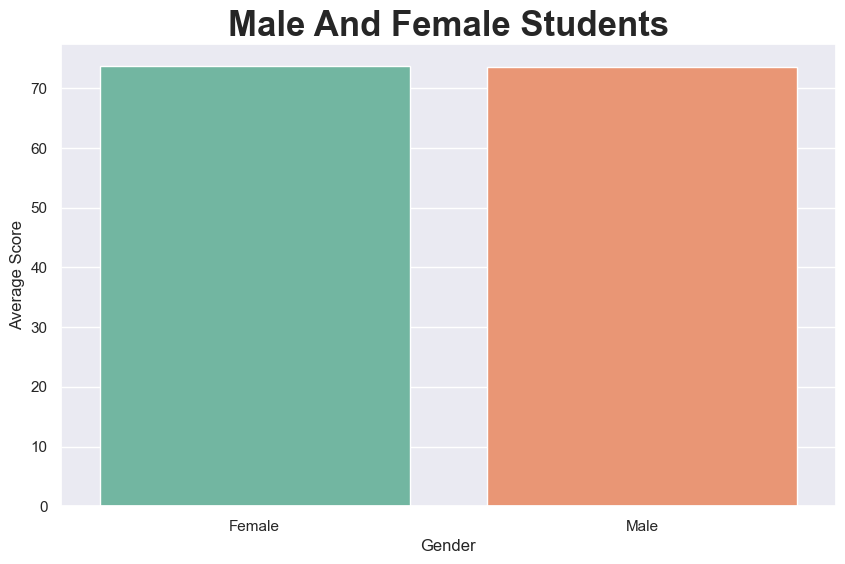

In [52]:
Gender_Avg = df.groupby("Gender")["Average Score"].mean().reset_index()
plt.figure(figsize = (10,6))

sns.set(style = "darkgrid")
sns.barplot(data = Gender_Avg, x = "Gender", y = "Average Score", hue = "Gender" ,palette= "Set2")
plt.title("Male And Female Students", fontsize = 25, fontweight = "bold")
plt.show()

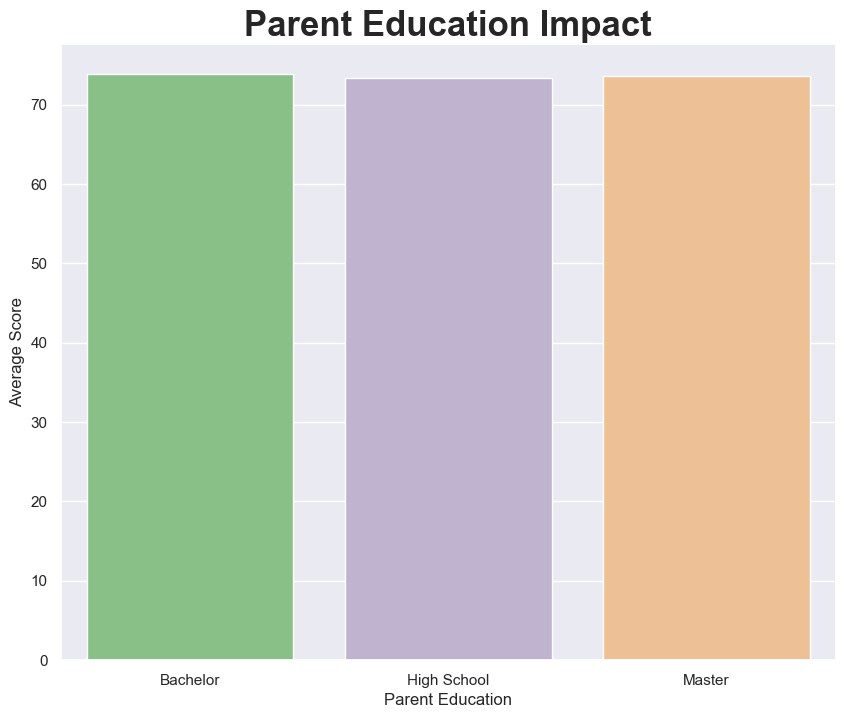

In [53]:
Parent_Avg = df.groupby("Parent Education")["Average Score"].mean().reset_index()

plt.figure(figsize = (10,8))
sns.barplot(data = Parent_Avg, x = "Parent Education",  y = "Average Score",
            hue = "Parent Education", palette= "Accent")

plt.title("Parent Education Impact", fontsize = 25, fontweight = "bold")
plt.show()

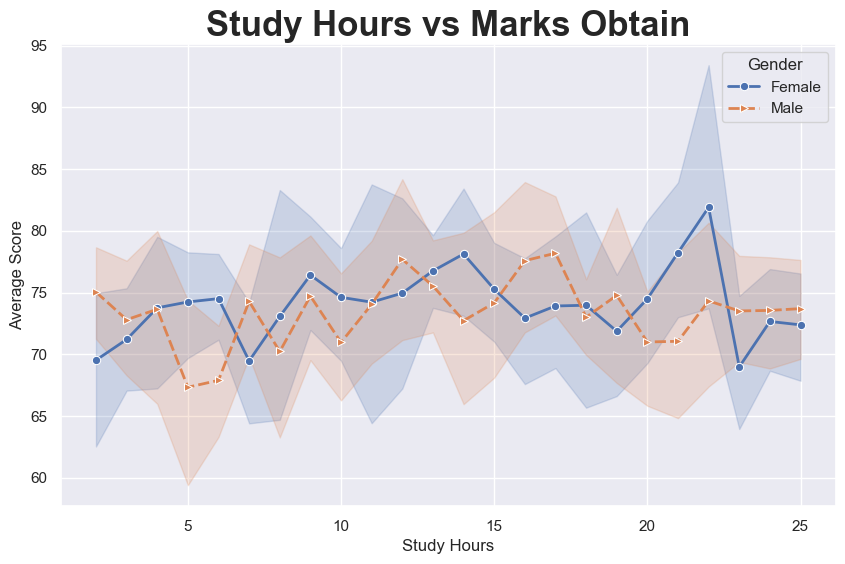

In [32]:
plt.figure(figsize = (10,6))
sns.lineplot(data = df, x = "Study Hours", y = "Average Score",hue = "Gender",style = "Gender",
             color = "g", linewidth = 2,markers=["o",">"])

plt.title("Study Hours vs Marks Obtain", fontsize = 25, fontweight = "bold")
plt.show()

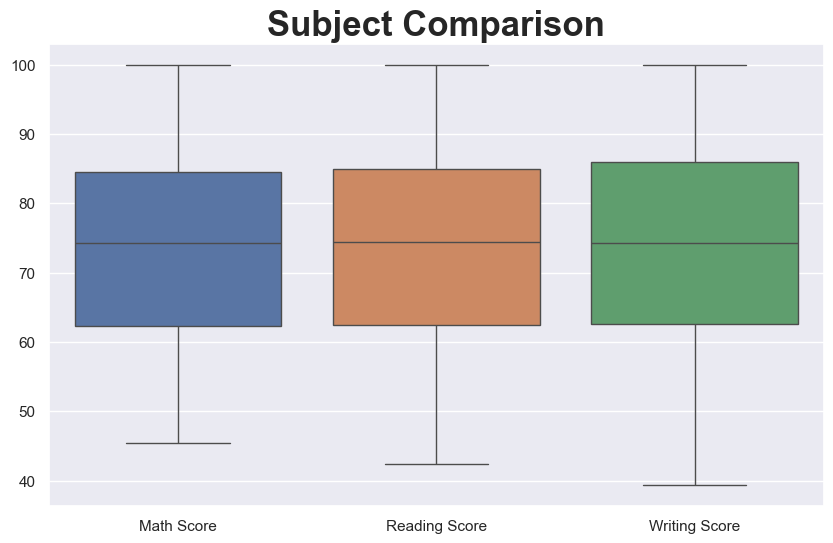

In [33]:
Subjects = df[["Math Score","Reading Score","Writing Score"]]
plt.figure(figsize = (10,6))

sns.boxplot(Subjects)

plt.title("Subject Comparison", fontsize = 25, fontweight = "bold")
plt.show()

In [34]:
Top_Performers = df.sort_values("Average Score",ascending= False).head(10)

print("Top Performers:\n",Top_Performers[["Gender", "Average Score"]])

Top Performers:
      Gender  Average Score
4    Female          97.33
10   Female          94.33
19   Female          93.87
111  Female          92.87
316    Male          91.80
0    Female          91.67
34   Female          91.40
329    Male          91.20
186  Female          90.87
391  Female          90.87


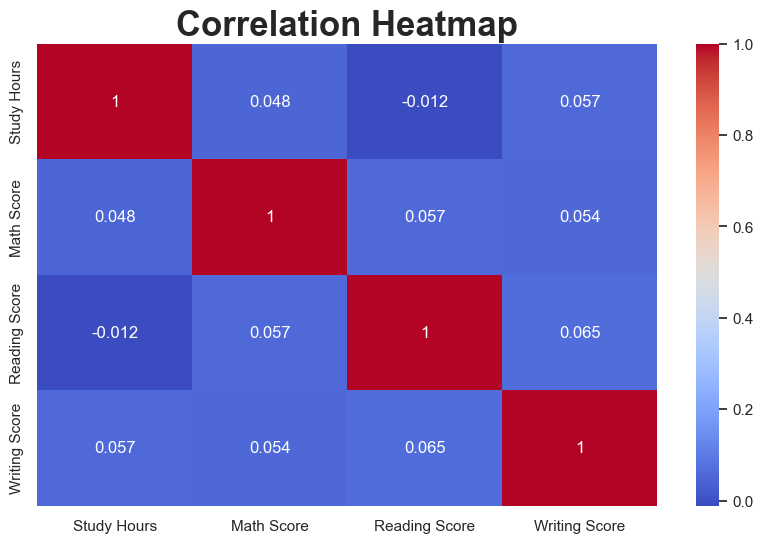

In [35]:
Corr_Heatmap = df[["Study Hours", "Math Score", "Reading Score", "Writing Score"]].corr()
plt.figure(figsize = (10,6))

sns.heatmap(Corr_Heatmap, annot= True, cmap= "coolwarm")

plt.title("Correlation Heatmap", fontsize = 25, fontweight = "bold")
plt.show()

In [36]:
def assign_grade(avg):
    if avg >= 90 :
        return "A"
    elif avg >= 75:
        return "B"
    elif avg >= 50:
        return "C"
    elif avg >= 40:
        return "D"
    else:
        return "Fail"

df["Assign Grade"] = df["Average Score"].apply(assign_grade)
df

,Student Name,Gender,Parent Education,Study Hours,Math Score,Reading Score,Writing Score,Total Score,Average Score,Assign Grade
0,Student_1,Female,Master,18,92.0,89.0,94.0,275.0,91.67,A
1,Student_2,Male,High School,8,62.0,58.0,60.0,180.0,60.00,C
2,Student_3,Female,Bachelor,14,78.0,82.0,80.0,240.0,80.00,B
3,Student_4,Male,High School,5,54.0,50.0,48.0,152.0,50.67,C
4,Student_5,Female,Master,22,98.0,95.0,99.0,292.0,97.33,A
...,...,...,...,...,...,...,...,...,...,...
413,Student_414,Female,Bachelor,7,78.0,72.6,55.4,206.0,68.67,C
414,Student_415,Male,High School,22,49.4,79.0,40.2,168.6,56.20,C
415,Student_416,Female,Master,13,77.6,64.2,92.4,234.2,78.07,B
416,Student_417,Female,Bachelor,6,63.4,73.8,62.2,199.4,66.47,C


In [48]:
Q1 = np.percentile(df["Average Score"],25)
Q3 = np.percentile(df["Average Score"],75)
IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Average Score"] < lower)|
    (df["Average Score"] > upper)
]

print("Outliers:", len(outliers))

Outliers: 0


In [45]:
Summary = {
    "Total Student" : len(df),
    "Average Score" : round(df["Average Score"].mean(),2),
    "Highest Score" : round(df["Average Score"].max(),2),
    "Lowest Score" : round(df["Average Score"].min(),2),
    "Grade A Count" : df["Assign Grade"].value_counts().get("A",0)
}

for k,v in Summary.items():
    print(f"{k}:{v}")

Total Student:418
Average Score:73.82
Highest Score:97.33
Lowest Score:50.67
Grade A Count:13


In [47]:
df.to_csv("UPDATED STUDENT ANALYSIS.csv")